# Building an Image-Based Recommendation System and Search Engine with Deep Learning and Elasticsearch

The notebook is related to the following medium story: **[Building an Image-Based Recommendation System and Search Engine with Deep Learning and Elasticsearch](https://medium.com/towards-artificial-intelligence/building-an-image-based-recommendation-system-and-search-engine-with-deep-learning-and-4bb96c4d9a64)**. Refer to this story for a detailed explanation.

### Setting up useful variables

In [1]:
import os
## The base dir of the project
PROJECT_DIR = "/home/projects/IBRS/Image-Based-Recommendation-System/02 - ResNet and Elasticsearch/"

## The "etc" dir contains all the files not tracked in GitHub
ETC_DIR = os.path.join(PROJECT_DIR, "etc")

## The .zip of the dataset is provided in the repository, but it's unzipped in "etc"
DATASET_ZIP_FILE = os.path.join(PROJECT_DIR, "dataset.zip")
DATASET_DIR = os.path.join(ETC_DIR, "dataset")
DATASET_METADATA_TXT_FILE = os.path.join(DATASET_DIR, "metadata.txt")
DATASET_METADATA_JSON_FILE = os.path.join(DATASET_DIR, "metadata.json")
DATASET_METADATA_DIR = os.path.join(DATASET_DIR, "metadata")

### Unzip the dataset

In [2]:
import zipfile

if not os.path.exists(DATASET_DIR):
    with zipfile.ZipFile(DATASET_ZIP_FILE, 'r') as data:
        data.extractall(path=ETC_DIR)
else:
    print('[INFO] Dataset already unzipped')

[INFO] Dataset already unzipped


### Generate a JSON metadata file from the TXT file

In [51]:
import json

metadata = []

if not os.path.exists(DATASET_METADATA_JSON_FILE):
    with open(DATASET_METADATA_TXT_FILE, 'r') as file :
        line = file.readline()
        while line:
            
            # read metadata of the current item
            item = eval(line.strip())
            
            metadata.append(item)
            
            # read the next line (next item)
            line = file.readline()
    
    with open(DATASET_METADATA_JSON_FILE, 'w') as file:
        json.dump(metadata, file)
else:
    print('[INFO] The JSON file already exists. Loading from disk')
    with open(DATASET_METADATA_JSON_FILE, 'r') as file:
        metadata = json.load(file)

The metadata file contains a list of metadata, as shown in the following example

```json
[
  {
    "ID": 7541,
    "title": "Christina Gavioli",
    "slug": "christina-gavioli-3",
    "category": [
      "Fashion Women",
      "Women Blouse and Dress"
    ],
    "imPath": "images/Fashion Women/Women Blouse and Dress/CHRISTINA_GAVIOLI.jpg"
  },
]
```

## Create the Elasticsearch Mapping to index the Data

In this tutorial, I'm using Elasticsearch as the data store and the vector database. Elasticsearch can perform vector or similarity search using KNN.

```json
"image_features": {
    "type": "dense_vector",
    "dims": 2048,
    "index": true,
    "similarity": "cosine"
}
```
* `dims`: The dimension should be the actual dimension of the dense vectors.
* `index`: When ***true*** (the default value), ES can perform vector search. It then creates an HNSW (Hierarchical Navigable Small World) index that is used to perform vector search. When it is set to ***false***, ES stores vectors but does not perform vector search. Useful only for storing embeddings for external processing. 
* `similarity`: The default value is ***cosine***. It defines the similarity metric that ES will use for vector search. Other metrics: *dot_product*, *l2_norm*

Vector store is available from Elasticsearch version 8+. Here, I'm using version 9.1.8.

Doc: [approximate-knn-search](https://www.elastic.co/docs/deploy-manage/production-guidance/optimize-performance/approximate-knn-search).

In [52]:
# define the mapping
mapping = {
  "mappings": {
    "properties": {
      "ID": {
        "type": "integer"
      },
      "title": {
        "type": "text",
        "fields": {
          "keyword": {
            "type": "keyword"
          }
        }
      },
      "slug": {
        "type": "text",
        "fields": {
          "keyword": {
            "type": "keyword"
          }
        }
      },
      "category": {
        "type": "keyword"
      },
      "imPath": {
        "type": "keyword"
      },
      "image_features": {
        "type": "dense_vector",
        "dims": 2048,
        "index": True,
        "similarity": "cosine"
      }
    }
  }
}

### Create the mapping using the Elasticsearch Python API

Make sur your Elasticsearch instance is up and running.

You can use the docker command below to run Elasticsearch.

```shell
docker run -d --name elasticsearch -p 9200:9200 -e "discovery.type=single-node" -e "xpack.security.enabled=false" elasticsearch:9.1.8
```
The `xpack.security.enabled=false` property is used to disable security for local development. It allows connecting and interacting with 
Elasticsearch with http://localhost:9200 without authentication.

In [53]:
from elasticsearch import Elasticsearch

es = Elasticsearch("http://localhost:9200")

index_name = "items"

if not es.indices.exists(index=index_name):
    es.indices.create(index=index_name, body=mapping)
    print("[INFO] Mapping create.")

[INFO] Mapping create.


In [54]:
metadata[0]

{'ID': 7541,
 'title': 'Christina Gavioli',
 'slug': 'christina-gavioli-3',
 'category': ['Fashion Women', 'Women Blouse and Dress'],
 'imPath': 'images/Fashion Women/Women Blouse and Dress/CHRISTINA_GAVIOLI.jpg'}

### Indexing the data in Elasticsearch

In [55]:
from elasticsearch.helpers import bulk

actions = [
    {
        "_index": index_name,
        "_id": item["ID"],
        "_source": item
    }
    for item in metadata
]

bulk(es, actions)
print("[INFO] Document indexed successfully")

[INFO] Document indexed successfully


In [56]:
es.search()

ObjectApiResponse({'took': 41, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 1655, 'relation': 'eq'}, 'max_score': 1.0, 'hits': [{'_index': 'items', '_id': '7541', '_score': 1.0, '_source': {'ID': 7541, 'title': 'Christina Gavioli', 'slug': 'christina-gavioli-3', 'category': ['Fashion Women', 'Women Blouse and Dress'], 'imPath': 'images/Fashion Women/Women Blouse and Dress/CHRISTINA_GAVIOLI.jpg'}}, {'_index': 'items', '_id': '7540', '_score': 1.0, '_source': {'ID': 7540, 'title': 'Sexy Woman', 'slug': 'sexy-woman-3', 'category': ['Fashion Women', 'Women Blouse and Dress'], 'imPath': 'images/Fashion Women/Women Blouse and Dress/SEXY_WOMAN_MULTICOLORE.jpg'}}, {'_index': 'items', '_id': '7539', '_score': 1.0, '_source': {'ID': 7539, 'title': 'Sexy Woman', 'slug': 'sexy-woman-2', 'category': ['Fashion Women', 'Women Blouse and Dress'], 'imPath': 'images/Fashion Women/Women Blouse and Dress/SEXY_WOMAN_JAUNE.jpg'}}, {'_in

## Extract Embeddings Using ResNet50

In [57]:
from tensorflow.keras.applications import resnet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import Model

import numpy as np

# Initialize the ResNet model with the Imagenet weights. You can use resnet.summary() to see the model structure
resnet = resnet50.ResNet50(weights='imagenet')

# create a submodel from the ResNet model
resnet_embeddings_extractor = Model(inputs=resnet.inputs, outputs=resnet.get_layer('avg_pool').output)

# uncomment the code below to see the resnet_embeddings_extractor structure
# resnet_embeddings_extractor.summary()

In [58]:
def load_image(path):
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)
    return x

def preprocess_batch(img_arrays):
    batch = np.stack(img_arrays, axis=0)
    return preprocess_input(batch)

def extract_embeddings_batch(paths):
    imgs = [load_image(path) for path in paths]
    batch = preprocess_batch(imgs)
    return resnet_embeddings_extractor.predict(batch, verbose=0)

def bulk_update_embeddings(es_client, items, embeddings):
    actions = []

    for item, vector in zip(items, embeddings):
        actions.append({
            "_op_type": "update",
            "_index": index_name,
            "_id": item["_id"],
            "doc": {
                "image_features": vector.flatten().tolist()
            }
        })

    bulk(es_client, actions)
    print(f"[INFO] updated {len(actions)} documents")

In [60]:
# Fetch items from Elasticsearch
query = {
    "size": 128,
    "query": {
        "bool": {
            "must_not": {
                "exists": {"field": "image_features"}
            }
        }
    }
}

response = es.search(
    index=index_name,
    body=query,
    scroll="5m"
)

scroll_id = response["_scroll_id"]

while True:
    hits = response["hits"]["hits"]

    if not hits:
        break

    # batch processing
    paths = [os.path.join(DATASET_DIR, hit["_source"]["imPath"]) for hit in hits]
    embeddings = extract_embeddings_batch(paths)
    bulk_update_embeddings(es, hits, embeddings)

    # continue scrolling
    response = es.scroll(scroll_id=scroll_id, scroll="5m")

print("DONE: all embeddings updated.")

[INFO] updated 128 documents
[INFO] updated 128 documents
[INFO] updated 128 documents
[INFO] updated 128 documents
[INFO] updated 128 documents
[INFO] updated 128 documents
[INFO] updated 128 documents
[INFO] updated 128 documents
[INFO] updated 128 documents
[INFO] updated 128 documents
[INFO] updated 128 documents
[INFO] updated 128 documents
[INFO] updated 119 documents
DONE: all embeddings updated.


## Perform Recommendations

* knn search with filter ref: https://www.elastic.co/docs/solutions/search/vector/knn#knn-search-filter-example

In [61]:
item_ids = [item['ID'] for item in metadata]

def knn_search(item_id, k=10, num_candidates=100, apply_filter=False):
    # Query Elasticsearch to get all the fields of the referenced item 
    res = es.get(index=index_name, id=item_id)
    ref_item = res['_source']

    # build the knn query. Add filter on category if apply_filter is enable
    knn_query = {
        "knn": {
            "field": "image_features",
            "query_vector": ref_item['image_features'],
            "k": k,
            "num_candidates": num_candidates
        }
    }

    
    if apply_filter:
        knn_query["knn"]["filter"] = {
            "term": {
                "category": ref_item['category'][0]
            }
        }
        
    # execute the knn query
    res = es.search(index=index_name, query=knn_query)
    knn_items = res['hits']['hits']
    return ref_item, knn_items

### Display Recommendations

In [62]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

def display_knn(knn_items, ref_item=None, src_img_path=None):
    # size of images in the grid
    fig = plt.figure(figsize = (16,3))
    
    # get image of the query item and display it in the matplotlib grid
    if ref_item is not None:
        ref_item_img = mpimg.imread(os.path.join(DATASET_DIR, ref_item['imPath']))
    elif src_img_path is not None:
        ref_item_img = mpimg.imread(src_img_path)
    else:
        raise ValueError('Expected ref_item or src_img_path, got None for both.')
    
    axis = []
    axis.append(fig.add_subplot(2,10,1))

    # display the query item
    axis[0].imshow(ref_item_img)
    plt.axis("off")
    
    # display the knn items: loop over the knn items and display their images
    for i, knn_item in enumerate(knn_items):
        knn_img = os.path.join(DATASET_DIR, knn_item['_source']['imPath'])
        axis.append(fig.add_subplot(2,10,i+11))
        axis[i+1].imshow(mpimg.imread(knn_img))
        plt.axis("off")
    
    # display the grid
    plt.show()

def make_recommendations(item_id, apply_filter=False):
    ref_item, knn_items = knn_search(item_id=item_id, apply_filter=apply_filter)
    display_knn(knn_items, ref_item=ref_item)

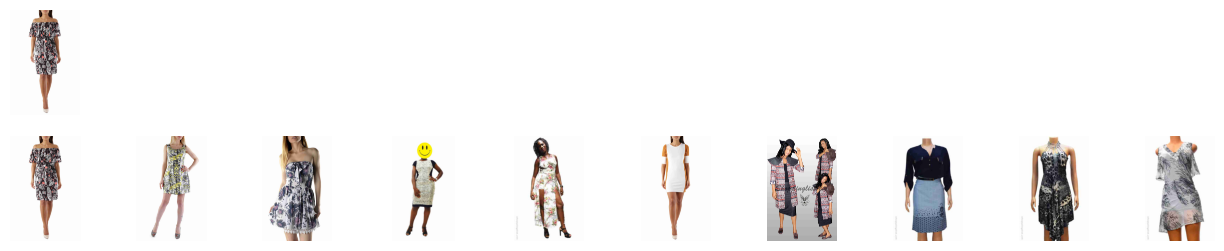

In [63]:
make_recommendations(item_id=7541)

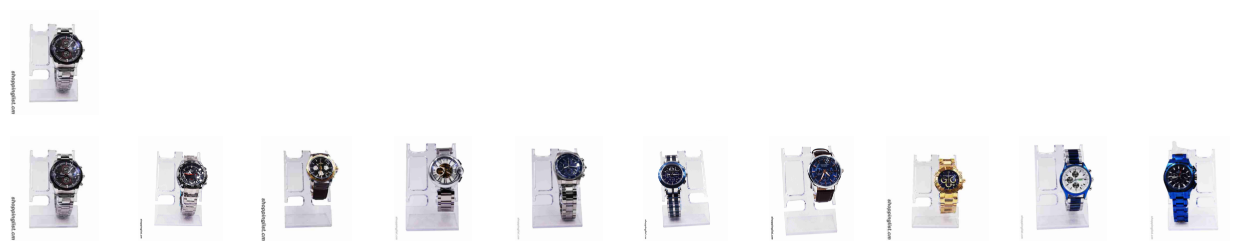

In [64]:
make_recommendations(item_id=6214)

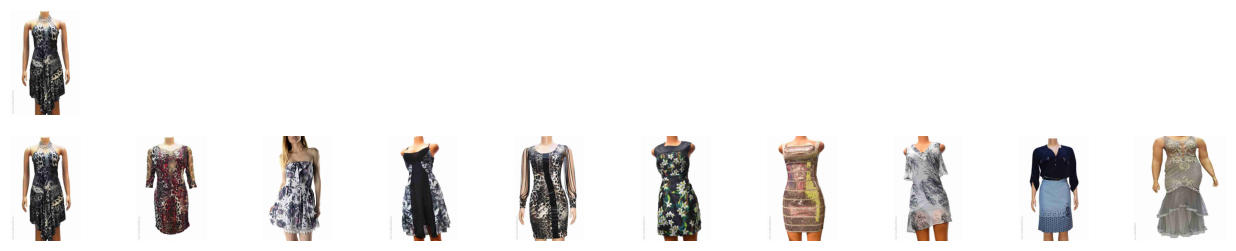

In [65]:
make_recommendations(item_id=5817)

### Example with and without filter

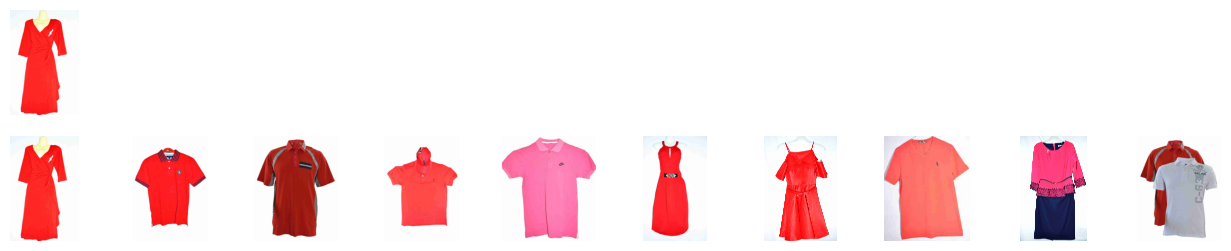

In [66]:
make_recommendations(item_id=1087)

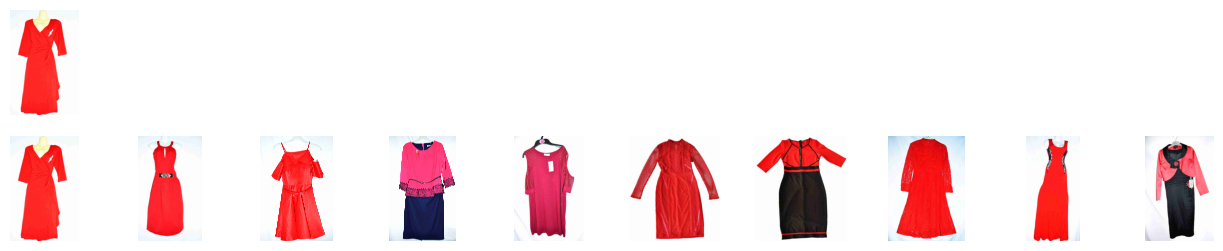

In [67]:
make_recommendations(item_id=1087, apply_filter=True)

In [68]:
import random
def random_item_search():
    # randomly select an item
    random_item_id = random.choice(item_ids)
    print(f"item id: {random_item_id}")

    # run the knn_search for the query item
    item, knns = knn_search(item_id=random_item_id)

    # display the results.
    display_knn(knns, ref_item=item)

item id: 6104


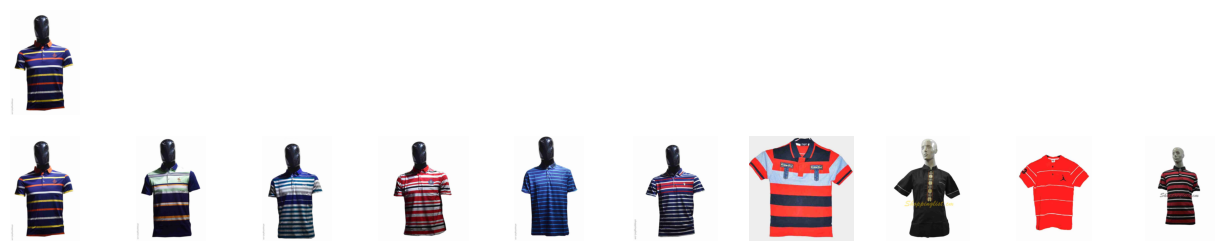

In [76]:
# explore other recommendations
random_item_search()

# Building an Image-based Search Engine

In [91]:
img_paths = [
    os.path.join(DATASET_DIR, 'img1.jpg'), # shoes
    os.path.join(DATASET_DIR, 'img2.png') # afritude
]

img_vectors = extract_embeddings_batch(paths=img_paths)

In [92]:
def image_based_search(src_vector, k=10, num_candidates=100):

    # build the knn query. Add filter on category if apply_filter is enable
    knn_query = {
        "knn": {
            "field": "image_features",
            "query_vector": src_vector,
            "k": k,
            "num_candidates": num_candidates
        }
    }
        
    # execute the knn query
    res = es.search(index=index_name, query=knn_query)
    knn_results = res['hits']['hits']
    return knn_results

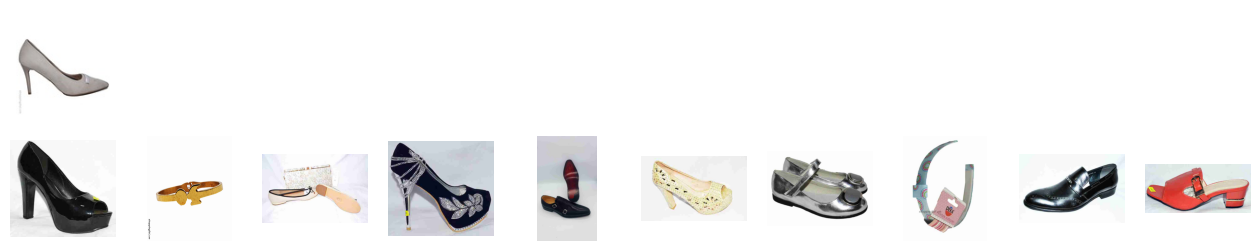

In [93]:
knn_results = image_based_search(img_vectors[0])
display_knn(knn_items=knn_results, src_img_path=img_paths[0])

Second example

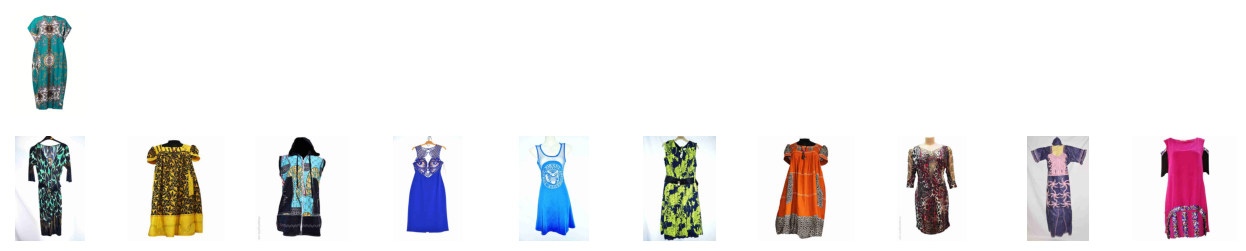

In [94]:
knn2_results = image_based_search(img_vectors[1])
display_knn(knn_items=knn2_results, src_img_path=img_paths[1])

The result is not the great, but as described in [this medium post](https://medium.com/towards-artificial-intelligence/building-an-image-based-recommendation-system-and-search-engine-with-deep-learning-and-4bb96c4d9a64), there is room for improvements.

One way to mitigate this issue is by applying a classification model to determine the category of the item in the image, then applying a filtered knn search using the predicted category.

## Enhancing Image Search Result with Image Classification

Two strategies can be applied for image classification:

* Using Classification models: it implies finetuning the model to our dataset
* Using multimodal models: using open-source LLM or LLM APIs with well crafted prompts.

In this notebook, I'm using Gemini multimodal API for image classification. The steps that should be completed to enhance the search results are the following:

* Extract the using list of categories from the metadata.json file or from the Elasticsearch index
* Crast the classification prompt for Gemini
* Update the search method to first classify the input image and then apply elasticsearch filtered knn

### Extract the List of categories from metadata

In [84]:
categories = sorted(list(set(item.get('category')[1] for item in metadata)))

In [100]:
from dotenv import load_dotenv
from google.genai import types

# reset the GEMINI_API_KEY env variable in case it has been changed from the credential file
os.environ.pop('GEMINI_API_KEY', None)

# load env variables from the credential file: it includes the GEMINI_API_KEY env variable
load_dotenv(dotenv_path=os.path.join(PROJECT_DIR, "etc/credentials/.env"))

# initialize the gemini client
client = genai.Client(api_key=os.getenv('GEMINI_API_KEY'))

# Set the classification knowledge base for the gemini api
CLASSIFIER_KB_PATH = os.path.join(DATASET_DIR, "classifier kb", "classifier_kb.pdf")
CLASSIFIER_KB = client.files.upload(file=CLASSIFIER_KB_PATH)

# set the model to use
MODEL_NAME = "gemini-2.0-flash"

# Create knowedge base cache and define system instructions

INSTRUCTIONS = """
You are an expert e-commerce item classifier.

The provided knowledge base contains the category definitions and four visual examples in a PDF format.

Study the knowledge base to understand the visual features of each category.

Your Goal is to classifier each provided image to exactly one category defined in the knowledge base.
"""

# Useful documentation

# https://ai.google.dev/api/caching
# https://googleapis.github.io/python-genai/genai.html#module-genai.caches
# https://googleapis.github.io/python-genai/genai.html#genai.types.CreateCachedContentConfig

# To use cache content, the cached content should have at least 4094 tokens: Cached content is too small. total_token_count=323, min_total_token_count=4096

In [101]:
def classify_with_gemini(query_img_path, classifier_kb=CLASSIFIER_KB):
    # Load user query image
    with open(query_img_path, "rb") as f:
        query_image_bytes = f.read()

    # Build Prompt
    prompt_parts = [
        # Add the knowledge base as part of the prompt
        classifier_kb,

        INSTRUCTIONS,
        
        # Add the new image to classify
        types.Part.from_bytes(data=query_image_bytes, mime_type='image/jpeg'),

        # task
        "Analyze the above image and assign it to exactly one category defined in the knowledge."
    ]

    # Call Gemini
    response = client.models.generate_content(
        model='gemini-2.0-flash',
        contents=prompt_parts,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema={
                "type": "object",
                "properties": {
                    "category": {
                        "type": "string",
                        "enum": categories
                    }
                },
                "required": ["category"]
            }
        )
    )
    
    return response.parsed

In [102]:
classify_with_pdf(img_paths[0], pdf_ref)

{'category': 'Women Shoes'}

### Author
Carmel WENGA, Data & ML Engineer
- [Medium](https://medium.com/@carmelwenga)
- [LinkedIn](https://www.linkedin.com/in/carmel-christian-wenga-871876178/)